# Raw SERS cohort commonality exploration

## tl;dr

이 노트북은 환자별 5개 raw replicate를 직접 불러와 다음을 한 화면에서 확인합니다.

1. 암 코호트 `PRO`, `BPRO`, `PAN(CPAN+YPAN)`, `OVA`를 **각각** 비교합니다.
2. `PRO+BPRO`처럼 묶은 확장 뷰도 별도로 제공합니다.
3. 건강 대조군 `NOR`, `YNOR`, `BNOR`와 질환 대조군 `DIA`, `HBP`, `H.D.`를 각각 비교합니다.
4. 여러 암종에서 같은 방향으로 차이가 나는 Raman shift 구간과, 정상-질환 대조군 간 차이 구간을 탐색합니다.

> **해석 제한:** 이 결과는 탐색적 후보 구간입니다. 병원, 장비 상태, 측정일, 전향/후향 수집 차이가 신호에 섞일 수 있으므로 biomarker로 단정할 수 없습니다. 특히 병원이 다른 cancer screening 비교는 hospital/acquisition confounding 가능성을 반드시 함께 보고해야 합니다.

## Context & Methods

### 라벨과 집계 규칙

- `PAN = CPAN + YPAN`; `SPAN`은 포함하지 않습니다.
- `BPRO`, `BNOR`는 Boramae acquisition cohort로 원본 라벨을 유지합니다.
- `strict_4class`: `PRO`, `PAN`, `OVA`, `Control(NOR+YNOR)`만 사용합니다.
- `expanded_4class`: `PRO+BPRO`, `PAN`, `OVA`, `Control(NOR+YNOR+BNOR)`로 묶어 보는 보조 뷰입니다.
- 건강 대조군 core는 `NOR+YNOR`, 질환 대조군은 `DIA`, `HBP`, `H.D.`를 각각 유지합니다.

### 신호 처리

- 로딩 시 공통 Raman grid로 선형 보간만 수행합니다.
- 환자 수준 비교에서는 5개 raw replicate의 산술평균을 사용합니다. `_ave` 파일은 학습/비교 입력으로 대체하지 않습니다.
- raw intensity와 replicate 표준편차를 먼저 확인합니다.
- 구간 위치 탐색용 effect size에는 환자별 median/IQR shape scaling을 추가로 사용합니다. 이 변환 결과는 절대 농도 차이가 아니라 **spectral shape 차이**입니다.
- 공통 구간은 기본적으로 `|Cohen's d| ≥ 0.5`가 모든 지정 비교에서 성립하고 방향이 같은 연속 구간으로 정의합니다. 아래 파라미터로 바꿀 수 있습니다.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src" / "sers").exists():
    raise FileNotFoundError("Run this notebook from the SERS-AI repo root or notebooks/ directory.")
sys.path.insert(0, str(ROOT / "src"))

from sers.io import parse_filename, read_spectrum

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)

DATA_ROOT = ROOT / "data" / "raw_data"
GRID = np.linspace(400, 2200, 933, dtype=np.float32)
EFFECT_THRESHOLD = 0.5
MIN_REGION_POINTS = 3


@dataclass(frozen=True)
class CohortSpec:
    folder: str
    group: str
    cancer: bool


@dataclass(frozen=True)
class PatientRecord:
    patient_key: str
    group: str
    cancer: bool
    replicates: np.ndarray
    average_present: bool


def resample_spectrum(path):
    x, y = read_spectrum(path)
    return np.asarray(np.interp(GRID, x, y), dtype=np.float32)


def average_sample_ids(cohort_dir):
    paths = list(cohort_dir.glob("*_ave.CSV")) + list(cohort_dir.glob("*_ave.csv"))
    for directory_name in ("Average data", "Averaged data"):
        average_dir = cohort_dir / directory_name
        paths.extend(average_dir.glob("*_ave.CSV"))
        paths.extend(average_dir.glob("*_ave.csv"))
    return {path.stem[:-4].rsplit(maxsplit=1)[-1] for path in paths}


def load_patient_records(data_root, cohorts):
    records = []
    for cohort in cohorts:
        cohort_dir = data_root / cohort.folder
        replicate_paths = {}
        for path in cohort_dir.iterdir():
            if not path.is_file() or path.suffix.casefold() != ".csv":
                continue
            try:
                spectrum_id = parse_filename(path, fallback_group=cohort.group)
            except ValueError:
                continue
            replicate_paths.setdefault(spectrum_id.sample_id, []).append((spectrum_id.replicate, path))
        averages = average_sample_ids(cohort_dir)
        for sample_id, indexed_paths in sorted(replicate_paths.items()):
            ordered_paths = [path for _, path in sorted(indexed_paths)]
            records.append(
                PatientRecord(
                    patient_key=f"{cohort.group}:{sample_id}",
                    group=cohort.group,
                    cancer=cohort.cancer,
                    replicates=np.stack([resample_spectrum(path) for path in ordered_paths]),
                    average_present=sample_id in averages,
                )
            )
    return tuple(sorted(records, key=lambda record: record.patient_key))


COHORTS = (
    CohortSpec("1. Prostate cancer (100개)", "PRO", True),
    CohortSpec("20260709_BPRO,BNOR_1mW_0.05s_Ave100/BPRO", "BPRO", True),
    CohortSpec("10-1. C-Pancreatic cancer (70개)", "CPAN", True),
    CohortSpec("10-3. Y-Pancreatic cancer (YPAN)", "YPAN", True),
    CohortSpec("3. Ovarian cancer (70개)", "OVA", True),
    CohortSpec("5. Normal (100개)", "NOR", False),
    CohortSpec("12. Y-Normal (YNOR)", "YNOR", False),
    CohortSpec("20260709_BPRO,BNOR_1mW_0.05s_Ave100", "BNOR", False),
    CohortSpec("6. Diabetes (100개)", "DIA", False),
    CohortSpec("7. High blood pressure (100개)", "HBP", False),
    CohortSpec("8. High blood pressure + Diabetes (100개)", "H.D.", False),
)

SOURCE_FAMILY = {
    "PRO": "legacy", "CPAN": "legacy", "OVA": "legacy", "NOR": "legacy",
    "DIA": "legacy", "HBP": "legacy", "H.D.": "legacy",
    "YPAN": "yonsei", "YNOR": "yonsei", "BPRO": "boramae", "BNOR": "boramae",
}

## Data

아래 셀에서 모든 코호트의 raw replicate를 불러옵니다. `inventory`에서 환자 수, replicate 수, 존재하는 `_ave` 파일 수를 먼저 확인하세요. 이후 분석은 `_ave` 파일의 존재만 inventory에 표시하며, 이후 분석은 `_ave`가 아니라 `replicates.mean(axis=0)`을 사용합니다.

In [2]:
records = load_patient_records(DATA_ROOT, COHORTS)
patient_spectra = np.stack([record.replicates.mean(axis=0) for record in records])
replicate_sd = np.stack([record.replicates.std(axis=0, ddof=1) for record in records])

meta = pd.DataFrame(
    {
        "patient_key": [record.patient_key for record in records],
        "source_group": [record.group for record in records],
        "source_family": [SOURCE_FAMILY[record.group] for record in records],
        "n_replicates": [len(record.replicates) for record in records],
        "average_present": [record.average_present for record in records],
    }
)
meta["analysis_group"] = meta["source_group"].replace({"CPAN": "PAN", "YPAN": "PAN"})
meta["strict_4class"] = meta["source_group"].map(
    {"PRO": "PRO", "CPAN": "PAN", "YPAN": "PAN", "OVA": "OVA", "NOR": "Control", "YNOR": "Control"}
)
meta["expanded_4class"] = meta["source_group"].map(
    {"PRO": "PRO", "BPRO": "PRO", "CPAN": "PAN", "YPAN": "PAN", "OVA": "OVA", "NOR": "Control", "YNOR": "Control", "BNOR": "Control"}
)

inventory = (
    meta.groupby(["source_family", "source_group"], sort=False)
    .agg(
        patients=("patient_key", "size"),
        raw_spectra=("n_replicates", "sum"),
        min_replicates=("n_replicates", "min"),
        max_replicates=("n_replicates", "max"),
        available_ave_files=("average_present", "sum"),
    )
    .reset_index()
)
inventory

,source_family,source_group,patients,raw_spectra,min_replicates,max_replicates,available_ave_files
0,boramae,BNOR,21,105,5,5,21
1,boramae,BPRO,99,495,5,5,99
2,legacy,CPAN,70,350,5,5,70
3,legacy,DIA,100,500,5,5,100
4,legacy,H.D.,100,500,5,5,100
5,legacy,HBP,100,500,5,5,100
6,legacy,NOR,100,500,5,5,100
7,legacy,OVA,70,350,5,5,70
8,legacy,PRO,100,500,5,5,100
9,yonsei,YNOR,29,145,5,5,0


In [3]:
def rows_for(groups):
    return meta["source_group"].isin(groups).to_numpy()

STRICT_GROUPS = {
    "PRO": ("PRO",),
    "PAN": ("CPAN", "YPAN"),
    "OVA": ("OVA",),
    "Control": ("NOR", "YNOR"),
}
EXPANDED_GROUPS = {
    "PRO": ("PRO", "BPRO"),
    "PAN": ("CPAN", "YPAN"),
    "OVA": ("OVA",),
    "Control": ("NOR", "YNOR", "BNOR"),
}

mapping_check = pd.DataFrame(
    [
        {"view": view, "class": label, "source_groups": ", ".join(groups), "patients": int(rows_for(groups).sum())}
        for view, mapping in (("strict", STRICT_GROUPS), ("expanded", EXPANDED_GROUPS))
        for label, groups in mapping.items()
    ]
)
mapping_check

,view,class,source_groups,patients
0,strict,PRO,PRO,100
1,strict,PAN,"CPAN, YPAN",100
2,strict,OVA,OVA,70
3,strict,Control,"NOR, YNOR",129
4,expanded,PRO,"PRO, BPRO",199
5,expanded,PAN,"CPAN, YPAN",100
6,expanded,OVA,OVA,70
7,expanded,Control,"NOR, YNOR, BNOR",150


## Results

### 1. Raw intensity와 replicate 변동

첫 번째 그래프는 환자별 replicate 평균의 코호트 평균입니다. 두 번째 그래프는 같은 환자에서 5회 반복 측정이 얼마나 흔들리는지 보여줍니다. 큰 차이가 보이더라도 acquisition/background 차이일 수 있습니다.

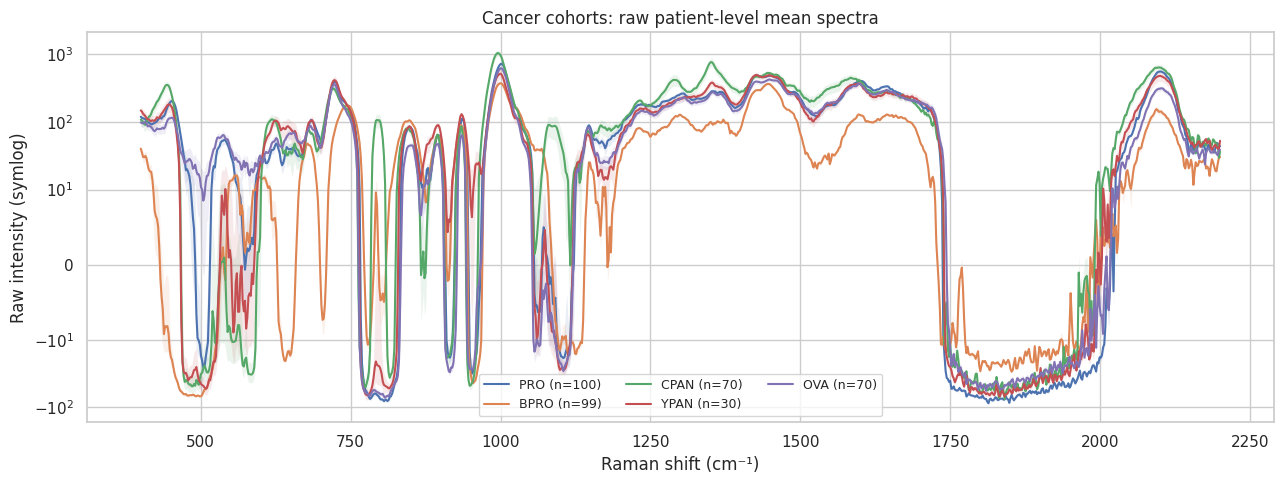

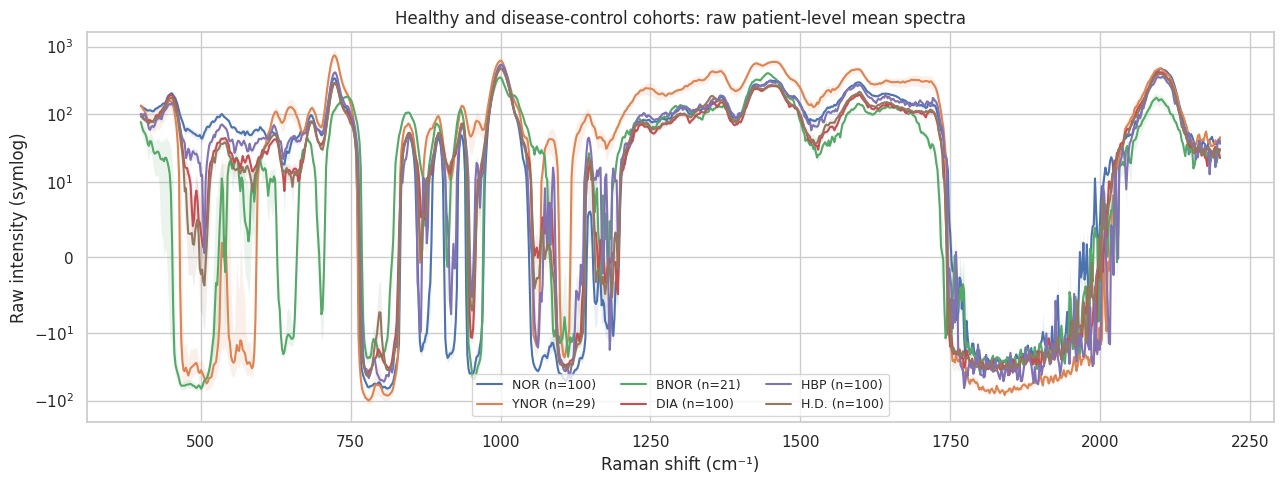

In [4]:
def plot_group_curves(values, groups, title, ylabel):
    fig, ax = plt.subplots(figsize=(13, 5))
    for group in groups:
        selected = values[rows_for((group,))]
        mean = selected.mean(axis=0)
        sem = selected.std(axis=0, ddof=1) / np.sqrt(len(selected))
        ax.plot(GRID, mean, label=f"{group} (n={len(selected)})")
        ax.fill_between(GRID, mean - sem, mean + sem, alpha=0.12)
    ax.set(title=title, xlabel="Raman shift (cm⁻¹)", ylabel=ylabel)
    ax.set_yscale("symlog", linthresh=10)
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    return fig

plot_group_curves(
    patient_spectra,
    ("PRO", "BPRO", "CPAN", "YPAN", "OVA"),
    "Cancer cohorts: raw patient-level mean spectra",
    "Raw intensity (symlog)",
)
plt.show()

plot_group_curves(
    patient_spectra,
    ("NOR", "YNOR", "BNOR", "DIA", "HBP", "H.D."),
    "Healthy and disease-control cohorts: raw patient-level mean spectra",
    "Raw intensity (symlog)",
)
plt.show()

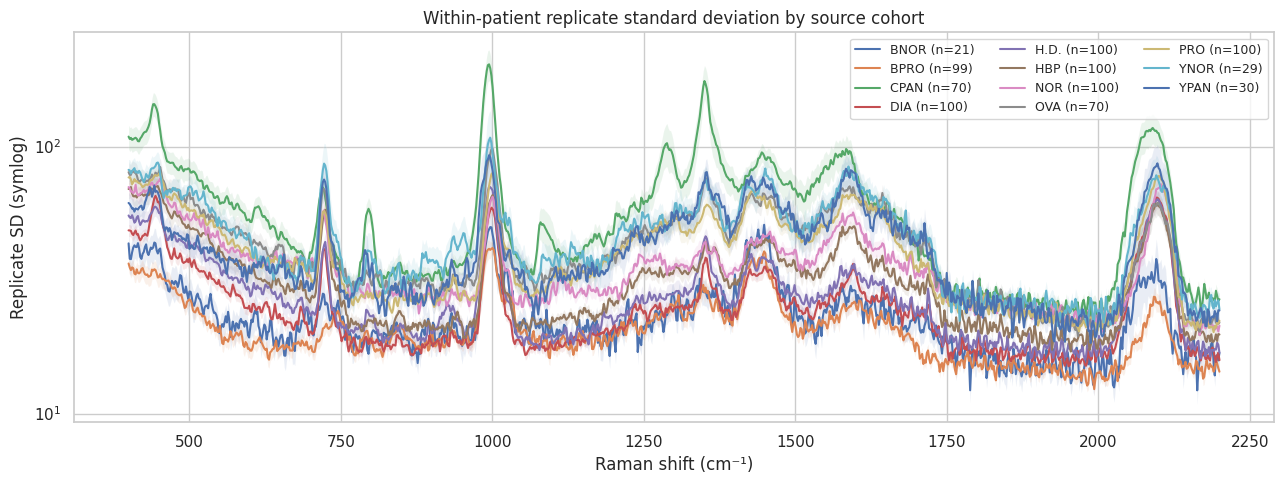

,replicate_sd_rms,noise_to_signal_rms
source_group,,
BNOR,27.295258,0.254949
BPRO,19.901724,0.223248
CPAN,66.559372,0.249638
DIA,26.697220,0.255640
H.D.,28.445812,0.263980
HBP,33.443058,0.259545
NOR,38.661995,0.274847
OVA,47.817863,0.296473
PRO,43.762131,0.226073


In [5]:
plot_group_curves(
    replicate_sd,
    tuple(inventory["source_group"]),
    "Within-patient replicate standard deviation by source cohort",
    "Replicate SD (symlog)",
)
plt.show()

noise_summary = meta[["patient_key", "source_group", "source_family"]].copy()
noise_summary["replicate_sd_rms"] = np.sqrt(np.mean(replicate_sd**2, axis=1))
noise_summary["raw_mean_rms"] = np.sqrt(np.mean(patient_spectra**2, axis=1))
noise_summary["noise_to_signal_rms"] = noise_summary["replicate_sd_rms"] / noise_summary["raw_mean_rms"].clip(lower=1e-8)
noise_summary.groupby("source_group", sort=False)[["replicate_sd_rms", "noise_to_signal_rms"]].median()

### 2. 구간 위치를 위한 shape effect size

아래 heatmap은 환자별 median을 빼고 IQR로 나눈 뒤 Cohen's d를 계산합니다. 전체 코호트 비교와 acquisition이 맞는 비교를 함께 둡니다.

- `PRO vs healthy core`, `PAN vs healthy core`, `OVA vs healthy core`: 암종 공통 후보 탐색
- `BPRO vs BNOR`, `YPAN vs YNOR`: 같은 수집 계열 내 비교
- `DIA/HBP/H.D. vs NOR`: legacy 정상-질환대조군 비교

색의 부호는 첫 번째 그룹이 두 번째 그룹보다 큰지/작은지를 뜻합니다.

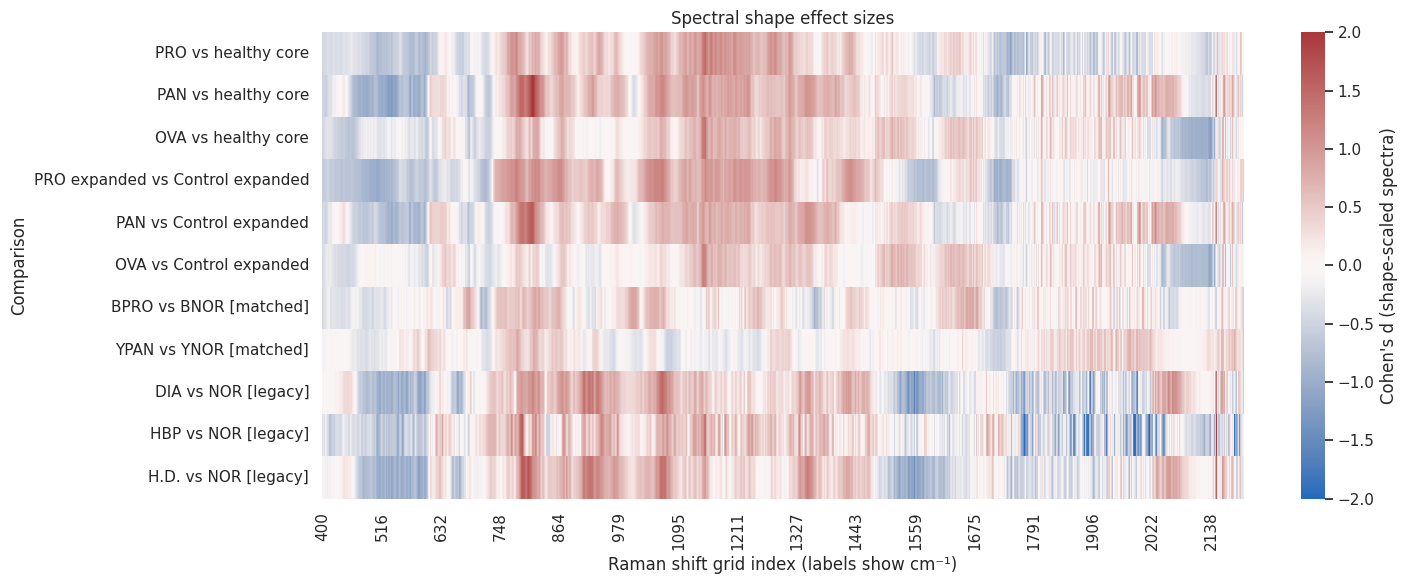

In [6]:
def robust_shape(values):
    median = np.median(values, axis=1, keepdims=True)
    q25 = np.percentile(values, 25, axis=1, keepdims=True)
    q75 = np.percentile(values, 75, axis=1, keepdims=True)
    return (values - median) / np.clip(q75 - q25, 1e-8, None)

shape_spectra = robust_shape(patient_spectra)

def matrix_for(groups, values=shape_spectra):
    return values[rows_for(groups)]

def cohens_d(groups_a, groups_b, values=shape_spectra):
    a, b = matrix_for(groups_a, values), matrix_for(groups_b, values)
    var_a = a.var(axis=0, ddof=1)
    var_b = b.var(axis=0, ddof=1)
    pooled = np.sqrt(((len(a) - 1) * var_a + (len(b) - 1) * var_b) / (len(a) + len(b) - 2))
    return (a.mean(axis=0) - b.mean(axis=0)) / np.clip(pooled, 1e-8, None)

HEALTHY_CORE = ("NOR", "YNOR")
COMPARISONS = {
    "PRO vs healthy core": (("PRO",), HEALTHY_CORE),
    "PAN vs healthy core": (("CPAN", "YPAN"), HEALTHY_CORE),
    "OVA vs healthy core": (("OVA",), HEALTHY_CORE),
    "PRO expanded vs Control expanded": (("PRO", "BPRO"), ("NOR", "YNOR", "BNOR")),
    "PAN vs Control expanded": (("CPAN", "YPAN"), ("NOR", "YNOR", "BNOR")),
    "OVA vs Control expanded": (("OVA",), ("NOR", "YNOR", "BNOR")),
    "BPRO vs BNOR [matched]": (("BPRO",), ("BNOR",)),
    "YPAN vs YNOR [matched]": (("YPAN",), ("YNOR",)),
    "DIA vs NOR [legacy]": (("DIA",), ("NOR",)),
    "HBP vs NOR [legacy]": (("HBP",), ("NOR",)),
    "H.D. vs NOR [legacy]": (("H.D.",), ("NOR",)),
}
effects = pd.DataFrame(
    {name: cohens_d(group_a, group_b) for name, (group_a, group_b) in COMPARISONS.items()},
    index=GRID,
).T

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    effects,
    cmap="vlag",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=60,
    cbar_kws={"label": "Cohen's d (shape-scaled spectra)"},
    ax=ax,
)
ax.set(xlabel="Raman shift grid index (labels show cm⁻¹)", ylabel="Comparison", title="Spectral shape effect sizes")
ax.set_xticklabels([f"{GRID[int(t.get_position()[0])]:.0f}" if int(t.get_position()[0]) < len(GRID) else "" for t in ax.get_xticklabels()])
plt.tight_layout()
plt.show()

### 3. 암종 공통 구간

두 가지 정의를 나란히 계산합니다.

- `strict`: `PRO/PAN/OVA` 각각을 healthy core `NOR+YNOR`와 비교
- `expanded`: `PRO+BPRO`, `PAN`, `OVA` 각각을 expanded control `NOR+YNOR+BNOR`와 비교

각 뷰에서 세 암종이 모두 threshold를 넘고 부호가 같은 구간만 뽑습니다. `BPRO vs BNOR`, `YPAN vs YNOR`의 같은 acquisition 비교도 별도 지지 근거로 남깁니다. 두 뷰에서 동시에 잡히는 구간은 `strict_expanded_overlap_regions`에서 확인합니다.

In [7]:
def contiguous_regions(mask, effect_rows, min_points=MIN_REGION_POINTS):
    padded = np.r_[False, mask, False]
    starts = np.flatnonzero(np.diff(padded.astype(int)) == 1)
    stops = np.flatnonzero(np.diff(padded.astype(int)) == -1)
    rows = []
    for start, stop in zip(starts, stops):
        if stop - start < min_points:
            continue
        region_effects = effect_rows[:, start:stop]
        rows.append(
            {
                "start_cm-1": float(GRID[start]),
                "end_cm-1": float(GRID[stop - 1]),
                "width_cm-1": float(GRID[stop - 1] - GRID[start]),
                "mean_abs_d": float(np.mean(np.abs(region_effects))),
                "direction": "higher" if np.mean(region_effects) > 0 else "lower",
            }
        )
    return pd.DataFrame(rows)


def common_direction_mask(effect_rows):
    return (effect_rows >= EFFECT_THRESHOLD).all(axis=0) | (effect_rows <= -EFFECT_THRESHOLD).all(axis=0)


def add_matched_support(regions):
    if regions.empty:
        return regions
    result = regions.copy()
    for column, effect_name in (
        ("BPRO_BNOR_same_direction_fraction", "BPRO vs BNOR [matched]"),
        ("YPAN_YNOR_same_direction_fraction", "YPAN vs YNOR [matched]"),
    ):
        matched_effect = effects.loc[effect_name].to_numpy()
        result[column] = [
            float(np.mean(np.sign(matched_effect[(GRID >= row["start_cm-1"]) & (GRID <= row["end_cm-1"])]) == (1 if row["direction"] == "higher" else -1)))
            for _, row in result.iterrows()
        ]
    return result

strict_names = ["PRO vs healthy core", "PAN vs healthy core", "OVA vs healthy core"]
expanded_names = ["PRO expanded vs Control expanded", "PAN vs Control expanded", "OVA vs Control expanded"]
strict_cancer_effects = effects.loc[strict_names].to_numpy()
expanded_cancer_effects = effects.loc[expanded_names].to_numpy()
strict_cancer_common_mask = common_direction_mask(strict_cancer_effects)
expanded_cancer_common_mask = common_direction_mask(expanded_cancer_effects)
strict_cancer_common_regions = add_matched_support(contiguous_regions(strict_cancer_common_mask, strict_cancer_effects))
expanded_cancer_common_regions = add_matched_support(contiguous_regions(expanded_cancer_common_mask, expanded_cancer_effects))
strict_expanded_overlap_mask = strict_cancer_common_mask & expanded_cancer_common_mask
strict_expanded_overlap_regions = contiguous_regions(
    strict_expanded_overlap_mask,
    np.vstack([strict_cancer_effects, expanded_cancer_effects]),
)

print("Strict common regions")
display(strict_cancer_common_regions.sort_values("mean_abs_d", ascending=False).head(20))
print("Expanded common regions")
display(expanded_cancer_common_regions.sort_values("mean_abs_d", ascending=False).head(20))
print("Strict ∩ expanded regions")
display(strict_expanded_overlap_regions.sort_values("mean_abs_d", ascending=False).head(20))

Strict common regions


,start_cm-1,end_cm-1,width_cm-1,mean_abs_d,direction,BPRO_BNOR_same_direction_fraction,YPAN_YNOR_same_direction_fraction
1,809.442078,822.961365,13.519287,1.046163,higher,1.000000,1.000
0,776.609436,790.128784,13.519348,0.973491,higher,1.000000,1.000
5,1058.583740,1072.103027,13.519287,0.901896,higher,1.000000,0.125
6,1116.523560,1216.952759,100.429199,0.888276,higher,0.566038,0.000
7,1230.472046,1236.266113,5.794067,0.804491,higher,1.000000,0.000
4,1046.995728,1052.789673,5.793945,0.777619,higher,1.000000,1.000
9,1303.862671,1321.244629,17.381958,0.760119,higher,0.700000,1.000
2,861.588013,875.107300,13.519287,0.752470,higher,1.000000,1.000
8,1269.098755,1298.068726,28.969971,0.741177,higher,1.000000,1.000
3,1037.339111,1041.201660,3.862549,0.685362,higher,1.000000,1.000


Expanded common regions


,start_cm-1,end_cm-1,width_cm-1,mean_abs_d,direction,BPRO_BNOR_same_direction_fraction,YPAN_YNOR_same_direction_fraction
2,1133.905640,1209.227417,75.321777,0.794078,higher,0.600,0.0
3,1274.892700,1296.137329,21.244629,0.732939,higher,1.000,1.0
4,1307.725342,1321.244629,13.519287,0.717457,higher,0.625,1.0
0,867.381958,873.175964,5.794006,0.696335,higher,1.000,1.0
1,1122.317627,1130.042969,7.725342,0.690420,higher,0.000,0.0


Strict ∩ expanded regions


,start_cm-1,end_cm-1,width_cm-1,mean_abs_d,direction
2,1133.905640,1209.227417,75.321777,0.855269,higher
1,1122.317627,1130.042969,7.725342,0.759728,higher
4,1307.725342,1321.244629,13.519287,0.756955,higher
3,1274.892700,1296.137329,21.244629,0.749403,higher
0,867.381958,873.175964,5.794006,0.745963,higher


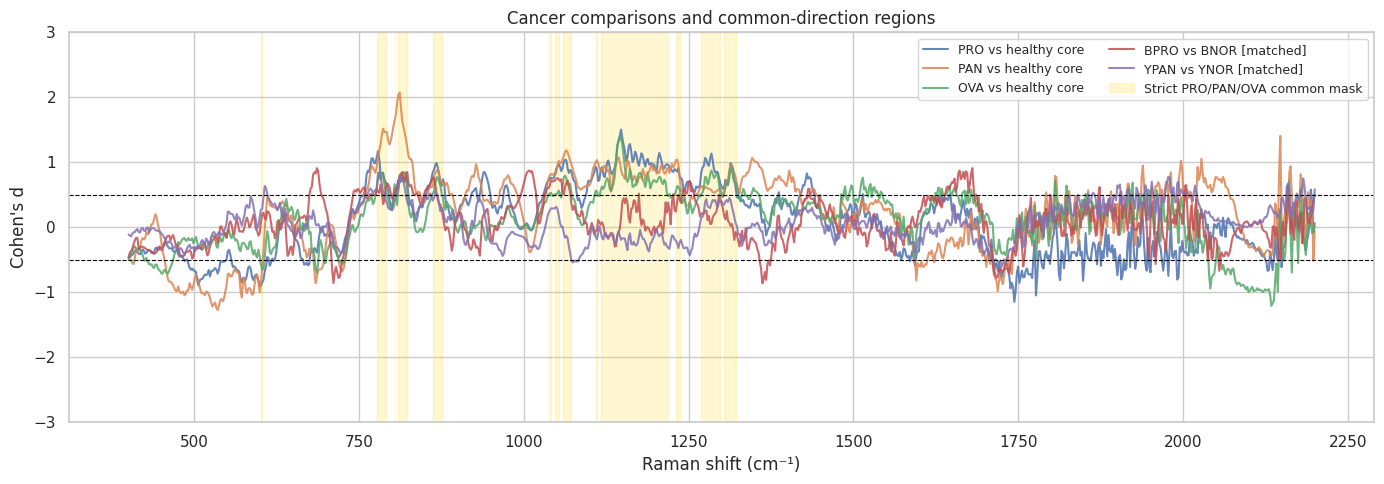

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
for name in strict_names + ["BPRO vs BNOR [matched]", "YPAN vs YNOR [matched]"]:
    ax.plot(GRID, effects.loc[name], label=name, alpha=0.85)
ax.axhline(EFFECT_THRESHOLD, color="black", lw=0.8, ls="--")
ax.axhline(-EFFECT_THRESHOLD, color="black", lw=0.8, ls="--")
ax.fill_between(GRID, -3, 3, where=strict_cancer_common_mask, color="gold", alpha=0.18, label="Strict PRO/PAN/OVA common mask")
ax.set(xlabel="Raman shift (cm⁻¹)", ylabel="Cohen's d", title="Cancer comparisons and common-direction regions", ylim=(-3, 3))
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

### 4. 건강 정상과 질환 대조군의 차이

`DIA`, `HBP`, `H.D.` 각각을 동일 legacy `NOR`와 비교합니다. 세 질환 대조군에서 모두 같은 방향으로 차이가 나는 구간을 표와 노란 음영으로 표시합니다. 이 구간은 암 특이 후보를 고를 때 제외하거나 nuisance/background feature로 모델에 명시적으로 학습시킬 우선 후보입니다.

,start_cm-1,end_cm-1,width_cm-1,mean_abs_d,direction
3,780.472107,793.991394,13.519287,1.105966,higher
10,1052.789673,1081.759644,28.969971,1.037594,higher
7,906.008606,913.733887,7.725281,1.018605,higher
4,809.442078,824.892700,15.450623,0.934760,higher
2,585.407715,595.064392,9.656677,0.911951,lower
12,1330.901245,1334.763916,3.862671,0.884622,higher
5,869.313293,875.107300,5.794006,0.873763,higher
8,934.978516,969.742493,34.763977,0.870340,higher
0,496.566528,560.300415,63.733887,0.849139,lower
11,1147.424927,1151.287598,3.862671,0.846044,higher


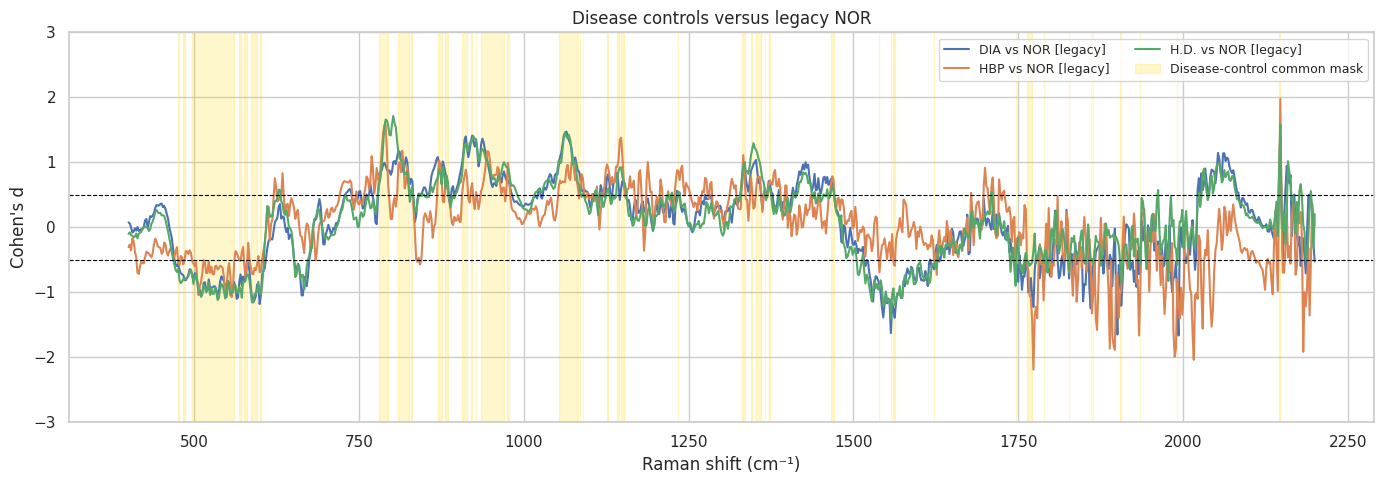

In [9]:
disease_names = ["DIA vs NOR [legacy]", "HBP vs NOR [legacy]", "H.D. vs NOR [legacy]"]
disease_effects = effects.loc[disease_names].to_numpy()
disease_common_mask = (disease_effects >= EFFECT_THRESHOLD).all(axis=0) | (disease_effects <= -EFFECT_THRESHOLD).all(axis=0)
disease_common_regions = contiguous_regions(disease_common_mask, disease_effects)

display(disease_common_regions.sort_values("mean_abs_d", ascending=False).head(20))

fig, ax = plt.subplots(figsize=(14, 5))
for name in disease_names:
    ax.plot(GRID, effects.loc[name], label=name)
ax.axhline(EFFECT_THRESHOLD, color="black", lw=0.8, ls="--")
ax.axhline(-EFFECT_THRESHOLD, color="black", lw=0.8, ls="--")
ax.fill_between(GRID, -3, 3, where=disease_common_mask, color="gold", alpha=0.2, label="Disease-control common mask")
ax.set(xlabel="Raman shift (cm⁻¹)", ylabel="Cohen's d", title="Disease controls versus legacy NOR", ylim=(-3, 3))
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Takeaways

- `inventory`로 각 source cohort의 환자 수와 5-replicate 완전성을 먼저 확인합니다.
- raw intensity 차이와 replicate SD 차이가 큰 구간은 모델이 질병보다 background/acquisition을 학습할 위험이 큽니다.
- `cancer_common_regions`는 PRO/PAN/OVA에서 공통으로 보이는 **탐색 후보**이며, Boramae·Yonsei matched comparison의 방향 일치율을 함께 봐야 합니다.
- `disease_common_regions`는 건강 정상과 비암성 질환 대조군을 구분하는 구간입니다. 암 공통 구간과 겹치면 암 특이성이 낮을 가능성이 있습니다.
- 다음 모델 단계에서는 환자 단위 split을 유지하고, raw 5-replicate set을 입력으로 쓰며, source-family stratification 또는 leave-one-acquisition-out 검증을 포함해야 합니다.

In [10]:
def overlap_fraction(mask_a, mask_b):
    denominator = mask_a.sum()
    return float((mask_a & mask_b).sum() / denominator) if denominator else np.nan

summary = pd.DataFrame(
    {
        "metric": [
            "loaded patients",
            "loaded raw spectra",
            "strict PRO/PAN/OVA common grid points",
            "expanded PRO/PAN/OVA common grid points",
            "strict-expanded overlapping cancer grid points",
            "disease-control common grid points",
            "stable cancer-common points overlapping disease-control mask",
        ],
        "value": [
            len(meta),
            int(meta["n_replicates"].sum()),
            int(strict_cancer_common_mask.sum()),
            int(expanded_cancer_common_mask.sum()),
            int(strict_expanded_overlap_mask.sum()),
            int(disease_common_mask.sum()),
            overlap_fraction(strict_expanded_overlap_mask, disease_common_mask),
        ],
    }
)
summary

,metric,value
0,loaded patients,819.000000
1,loaded raw spectra,4095.000000
2,strict PRO/PAN/OVA common grid points,128.000000
3,expanded PRO/PAN/OVA common grid points,74.000000
4,strict-expanded overlapping cancer grid points,74.000000
5,disease-control common grid points,170.000000
6,stable cancer-common points overlapping diseas...,0.148649
